# <span style="color: purple;">Lesson 4 - Exploring Data</span>

**Developers:** Mungo &nbsp;|&nbsp; **Reviewers:** Alina

---

## <span style="color: purple;">🎯 Learning Objectives</span>

By the end of this lesson, you will have:

- Loaded a real dataset
- Explored how the dataset is organised
- Calculated summary statistics
- Visualised relationships between variables

<div class="alert alert-info">

**How it works:** Click the ▶ button on the top left of each code cell, top to bottom. Read the explanation after you see the output. That's it!

</div>

In [14]:
# ─────────────────────────────────────────────────────────────
# Setup cell — run this first, then you can ignore it
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

print("✓ Ready to go!")

✓ Ready to go!


---

## <span style="color: purple;">🧭 Overview</span>

Before we build a model, we need to understand our data.

<div class="alert alert-success">

**Data exploration** - Looking at a dataset carefully to understand what is inside it, what patterns it has, and what might be useful for modelling.

</div>

In this lesson, we will use a real dataset and use simple charts to spot patterns.

<div class="alert alert-success">

**Features** - The measured values in each row that we can use for analysis or prediction.

</div>

---

## <span style="color: purple;">Step 1 - Load and inspect the dataset</span>

We will use a Spotify songs dataset stored in this repository. Each row is one record, with columns we can explore and visualise.

<div class="alert alert-info">

Run the next cell to load the data and inspect its shape.

</div>

In [ ]:
file_path = 'spotify_alltime_top100_songs.csv'
df = pd.read_csv(file_path)

df.drop(columns=["dataset_part"], inplace=True)
df.set_index('alltime_rank', inplace=True)

# Renaming columns for better readability in the notebook
df = df.rename(columns={
    'song_title': 'Song Title',
    'artist': 'Artist',
    'total_streams_billions': 'Total Streams (Billions)',
    'primary_genre': 'Primary Genre',
    'bpm': 'BPM',
    'release_year': 'Release Year',
    'artist_country': 'Artist Country',
    'explicit': 'Explicit',
    'danceability': 'Danceability',
    'energy': 'Energy',
    'valence': 'Valence',
    'acousticness': 'Acousticness'
})

print("First 5 records:")
display(df.head())
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("✓ Dataset loaded and previewed")

First 5 records:


,Song Title,Artist,Total Streams (Billions),Primary Genre,BPM,Release Year,Artist Country,Explicit,Danceability,Energy,Valence,Acousticness
alltime_rank,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00
2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08
3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29
4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15
5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09


Rows: 100
Columns: 12
✓ Dataset loaded and previewed


The first five rows show the structure of the dataset. Each row is one song and each column is one feature.

Next, we will calculate summary statistics to understand typical values and spread in the numeric columns.

---

## <span style="color: purple;">Step 2 - Calculate summary statistics</span>

Summary statistics help us quickly see the centre and spread of each feature.

<div class="alert alert-success">

**Summary statistics** - Quick numbers (like mean, minimum, and maximum) that describe the overall pattern of a feature.

</div>

<div class="alert alert-info">

Run the code to view count, mean, minimum, and maximum values.

</div>

In [16]:
numeric_columns = df.select_dtypes(include='number').columns.tolist()

if len(numeric_columns) == 0:
    raise ValueError('No numeric columns found for summary statistics.')

stats_table = df[numeric_columns].describe().T[['count', 'mean', 'std', 'min', 'max']]
display(stats_table.head(10))
print(f"Numeric columns found: {len(numeric_columns)}")
print("✓ Summary statistics shown")

,count,mean,std,min,max
Total Streams (Billions),100.0,2.5246,0.851432,1.40,5.26
BPM,100.0,115.7800,30.540776,62.00,191.00
Release Year,100.0,2016.8000,7.063922,1985.00,2024.00
Danceability,100.0,0.6135,0.142888,0.30,0.90
Energy,100.0,0.6361,0.163824,0.26,0.96
Valence,100.0,0.5506,0.238623,0.07,0.96
Acousticness,100.0,0.1534,0.164637,0.00,0.76


Numeric columns found: 7
✓ Summary statistics shown


These numbers tell us how large values usually are and how much they vary.

Numbers are useful, but plots make patterns much easier to spot.

---

## <span style="color: purple;">Step 3 - Plot a histogram</span>

A histogram shows how values are distributed for one feature.

<div class="alert alert-info">

Run this to see the distribution of the first numeric column in the dataset.

</div>

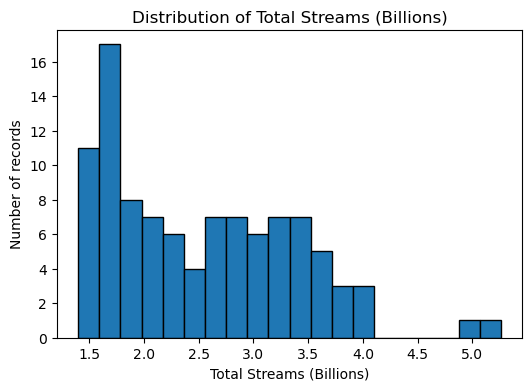

Using feature: Total Streams (Billions)
✓ Histogram created


In [17]:
hist_feature = numeric_columns[0]

plt.figure(figsize=(6, 4))
plt.hist(df[hist_feature].dropna(), bins=20, edgecolor='black')
plt.title(f'Distribution of {hist_feature}')
plt.xlabel(hist_feature)
plt.ylabel('Number of records')
plt.show()
print(f"Using feature: {hist_feature}")
print("✓ Histogram created")

The histogram shows how common different values are for that feature.

Now let's compare two numeric features at the same time with a scatter plot.

---

## <span style="color: purple;">Step 4 - Examine relationships with a scatter plot</span>

A scatter plot helps us see if two features move together or form groups.

<div class="alert alert-success">

**Visualisation** - Using charts or plots to make patterns in data easier to understand.

</div>

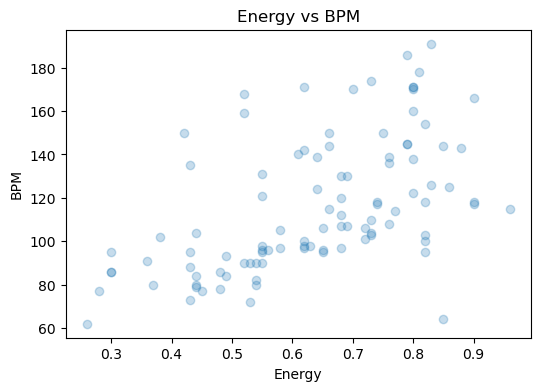

Using features: Energy and BPM
✓ Scatter plot created


In [18]:
if len(numeric_columns) < 2:
    raise ValueError('Need at least 2 numeric columns for a scatter plot.')

x_feature = 'Energy'
y_feature = 'BPM'

plt.figure(figsize=(6, 4))
plt.scatter(df[x_feature], df[y_feature], alpha=0.25)
plt.title(f'{x_feature} vs {y_feature}')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.show()
print(f"Using features: {x_feature} and {y_feature}")
print("✓ Scatter plot created")

<div class="alert alert-info">

Each dot is one record. Scatter plots help you see whether two features tend to increase together, decrease together, or show no clear relationship.

This is why exploration matters: we learn useful structure before building any model.

</div>

---

## <span style="color: purple;">🧠 Summary</span>

In this lesson, you loaded a real dataset, inspected its structure, computed summary statistics, and created both a histogram and a scatter plot.

Exploring data first helps you make better modelling choices because you can see feature ranges, spread, and relationships before training anything.

### Key words

| Word | What it means |
|------|--------------|
| **Features** | Measured columns in the dataset |
| **Summary statistics** | Quick numbers that describe a feature, like mean, minimum, and maximum |
| **Data exploration** | Investigating structure and patterns in the data |
| **Visualisation** | Using charts to understand data patterns |

---

## <span style="color: purple;">🔧 Challenge</span>

Try different pairs of numeric features below, then re-run the cell. Which pair gives the strongest relationship (highest absolute correlation)?

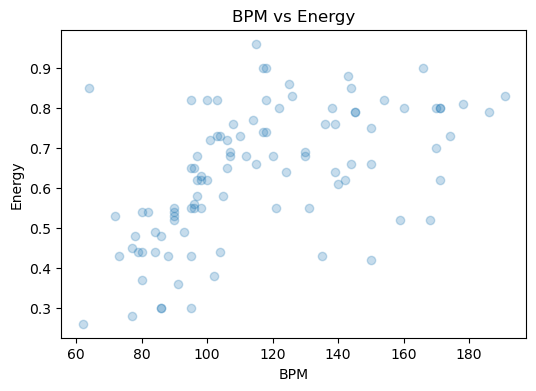

Correlation between BPM and Energy: 0.54
✓ Challenge plot created


In [21]:
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼  CHANGE THIS  ▼▼▼▼▼▼▼▼▼▼▼▼▼▼
x_feature = 'BPM'               # ← try 'Danceability', 'BPM', or 'Valence'
y_feature = 'Energy'         # ← try 'Total Streams Billions' or 'Acousticness'
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲  CHANGE THIS  ▲▲▲▲▲▲▲▲▲▲▲▲▲▲

plt.figure(figsize=(6, 4))
plt.scatter(df[x_feature], df[y_feature], alpha=0.25)
plt.title(f'{x_feature} vs {y_feature}')
plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.show()

correlation = df[x_feature].corr(df[y_feature])
print(f'Correlation between {x_feature} and {y_feature}: {correlation:.2f}')
print('✓ Challenge plot created')

---

## <span style="color: purple;">🧪 Quick Quiz</span>

Test yourself on what you just learned. Run the code cell, choose your answers, then click **Check answers**.

In [20]:
from quiz import run_b04_quiz
run_b04_quiz()